# Non-Uniform Azimuthal Poisson Solver:
# Jittered Angular Grid vs. Uniform FFT with Interpolation


u(x,y) = (R^2 - x^2 - y^2) \exp(x) \sin(k y)


This manufactured nonseparable Cartesian problem is smooth on the full disk,
including at the origin, and satisfies homogeneous Dirichlet boundary conditions:


u(R,\theta)=0.


The angular grid is a jittered mesh: each angle is a uniform cell-center
position perturbed by up to a fixed fraction of one cell width.

All methods begin with the same jittered angular measurements. Adapted NUFFT
(using the Toeplitz/Block-CG solver) and Adapted NUDFT consume those
measurements directly. The Uniform FFT baseline first applies periodic cubic
spline interpolation to place the same measurements on a uniform angular grid
before solving.

In [1]:
import os
import sys
from pathlib import Path



# ---------------------------------------------------------
# Backend & Environment Configuration
# ---------------------------------------------------------
USE_GPU = True  # Set to True for NVIDIA GPU acceleration

# Auto-detect Google Colab
IN_COLAB = 'google.colab' in sys.modules or os.environ.get('COLAB_GPU') is not None
if IN_COLAB:
    if not os.path.exists('Poisson_Solver'):
        os.system('git clone https://github.com/CharliePyle4/NUFFTRR_Poisson.git')
        if os.path.exists('NUFFTRR_Poisson'):
            os.chdir('NUFFTRR_Poisson')
    os.system('pip install -r requirements.txt -q')
    if USE_GPU:
        os.system('pip install cufinufft -q')
    !cd /content/NUFFTRR_Poisson && git pull


# Dynamic repository root and helper path resolution
repo_root = str(Path.cwd().resolve())
while repo_root and not os.path.exists(os.path.join(repo_root, 'Poisson_Solver')):
    parent = str(Path(repo_root).parent)
    if parent == repo_root:
        break
    repo_root = parent
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

tests_dir = os.path.join(repo_root, 'Tests', 'paper')
if tests_dir not in sys.path:
    sys.path.insert(0, tests_dir)

# Solver Parameters (Unsquared PCGLS with Pipe & Menon density compensation)
num_processors = None    # Number of CPU threads (None = all available cores)
maxiter_nufft = 100      # Maximum PCGLS iterations
tol_nufft = 1e-8        # PCGLS convergence tolerance
reg_param = 1e-20        # Tikhonov regularization
eps_finufft = 1e-8      # FINUFFT kernel precision

# Multi-Run Benchmark Timing Configuration
TIME_TRIALS = True  # Set to True to run each test 5 times and record min runtime
NUM_RUNS = 5 if TIME_TRIALS else 1

backend_name = 'GPU (NVIDIA CuPy / cuFINUFFT)' if USE_GPU else 'CPU (Multithreaded FINUFFT)'
print('=' * 60)
print(f'  Executing PCGLS Test Suite on: {backend_name}')
print('=' * 60)
from slight_nonuniform_helpers import *
set_timing_config(time_trials=TIME_TRIALS, num_runs=NUM_RUNS, use_gpu=USE_GPU)

import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Current device:", device)


Already up to date.
  Executing PCGLS Test Suite on: GPU (NVIDIA CuPy / cuFINUFFT)
Current device: cuda


## 1. Configurable Parameters & Setup
All problem, mesh, and solver parameters are configured in the cell below:

In [2]:
# ---------------------------------------------------------
# Disk and smooth single-multipole manufactured problem
# ---------------------------------------------------------
R = 1.0
k = 32 


# ---------------------------------------------------------
# Jittered angular mesh
#
# Each angle is a uniform cell-center perturbed within its sector:
#   theta_j = 2*pi/N * (j + 1/2) + delta_j,
#   |delta_j| <= jitter_fraction * (2*pi/N).
# ---------------------------------------------------------
JITTER_FRACTION = 0.45
GRID_SEED = 42


# ---------------------------------------------------------
# Solver settings
# ---------------------------------------------------------
QUAD_RULE = 2                # 1: Trapezoidal, 2: Simpson
BC_CHOICE = 1                # 1: Dirichlet, 2: Neumann


# ---------------------------------------------------------
# Resolution study
#
# MODE=16 needs enough angular samples. N=64 is the first
# meaningful resolution in this study.
# ---------------------------------------------------------
N_VALUES = [128, 256, 512, 1024]
M_VALUES = [128, 256, 512, 1024]


# ---------------------------------------------------------
# Fixed settings for plots
# ---------------------------------------------------------
N_LOW_ADAPT = 128
N_HIGH_UNIFORM = 1024
M_FIXED_PLOTS = 1024

## 2. Problem Setup and Disk Grid Visualization
3D analytical solution $u(x,y)$ on the disk, clean polar grid comparison, and 1D angular slice profile.

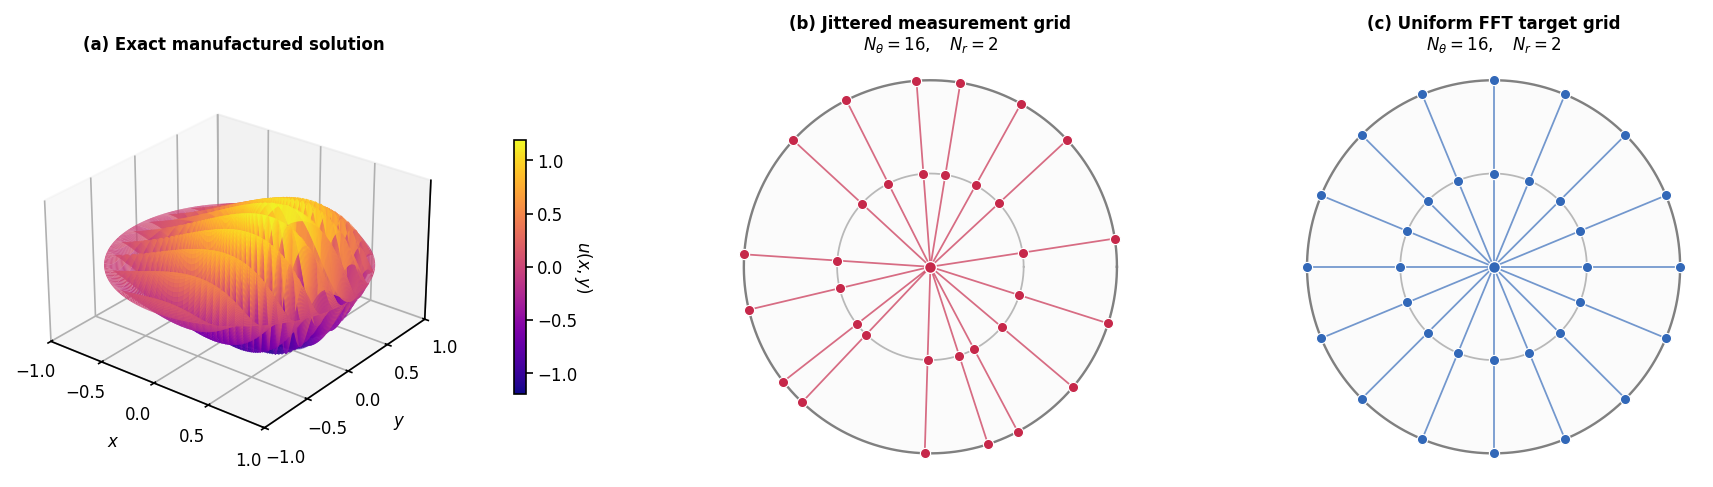

In [3]:
from Tests.paper.slight_nonuniform_helpers import get_cartesian_mixed_problem
# Construct smooth Cartesian mixed manufactured problem.
problem = get_cartesian_mixed_problem(
    R=R,
    k=k,
)

# Visualize exact solution, jittered measurement grid,
# and Uniform FFT target grid.
plot_solution_and_grids(
    problem=problem,
    N_adapt=16,
    N_unif=16,
    M=2,
    jitter_fraction=JITTER_FRACTION,
    grid_seed=GRID_SEED,
)

## 3. $N$ vs. $M$ Grid Study for All Three Algorithms
We compute the full $(N \times M)$ matrix of relative $L_2$ errors and execution times for **Adapted NUFFT**, **Adapted NUDFT**, and **Uniform FFT**.

In [4]:
df_results = run_all_algorithms_NxM_study(
    problem=problem,
    N_values=N_VALUES,
    M_values=M_VALUES,
    jitter_fraction=JITTER_FRACTION,
    grid_seed=GRID_SEED,
    bc_choice=BC_CHOICE,
    quad_rule=QUAD_RULE,
    maxiter_nufft=maxiter_nufft,
    tol_nufft=tol_nufft,
    reg_param=reg_param,
    eps_finufft=eps_finufft,
    num_processors=num_processors,
    use_gpu=USE_GPU,
)

Computing N x M jittered-grid study [GPU]:   0%|          | 0/48 [00:00<?, ?it/s]

## 4. $L_2$ Error 
Relative $L_2$ error tables for each algorithm across $N$ (rows) and $M$ (columns).

In [5]:
# Relative L2 Error Tables for each algorithm
combined_error = render_combined_error_table(df_results, value_col="L2_rel")

## 5. Convergence & Runtime Curves
Plots of Accuracy vs. $N$ (fixed $M$), Accuracy vs. $M$ (fixed $N$), and Runtime vs. $N$ for all three algorithms.

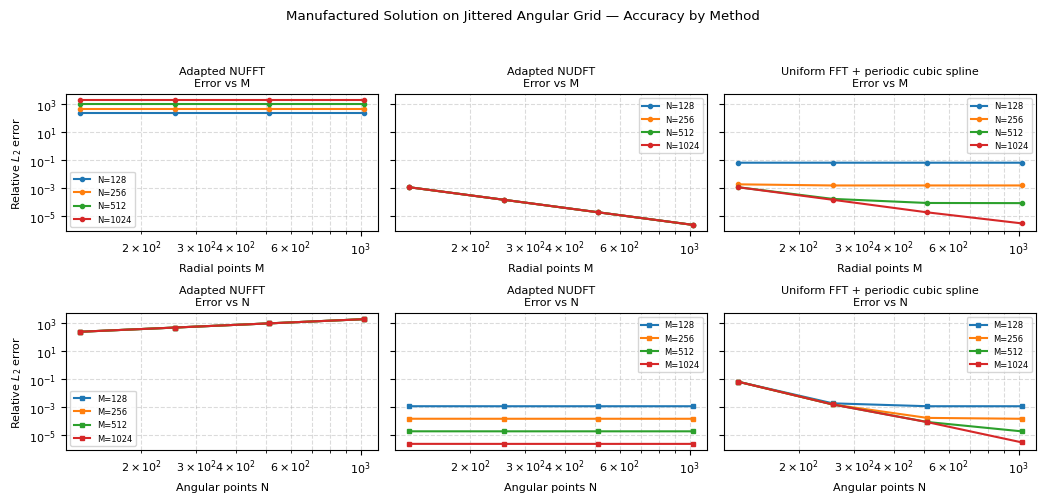

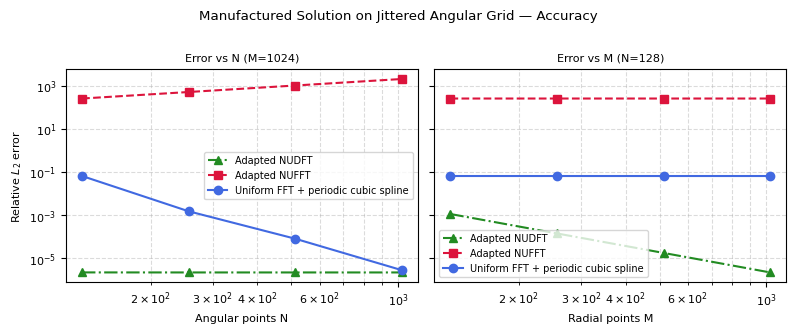

In [6]:
plot_accuracy_faceted_by_method(df_results, N_values=N_VALUES, M_values=M_VALUES)

plot_accuracy_from_df(
    df_results=df_results,
    fixed_M=1024,
    fixed_N=N_LOW_ADAPT
)

## 7. Disk Error Comparison with Higher-Resolution Uniform Grid
Side-by-side 3D error surfaces comparing Adapted NUFFT ($N=32$) and Adapted NUDFT ($N=32$) against the higher-resolution Uniform FFT ($N=256$).


1 x 3 Disk Error Comparison with NUDFT Table Result
                                                   Case    N    M Relative L2 Relative Linf Runtime (s)
                   Adapted NUFFT — direct jittered data  128 1024   2.550e+02     2.550e+02      0.2894
                   Adapted NUDFT — direct jittered data  128 1024   2.231e-06     3.513e-06      0.2235
  Uniform FFT + interpolation — same measurement budget  128 1024   6.538e-02     1.044e-01      0.0136
Uniform FFT + interpolation — higher measurement budget 1024 1024   2.848e-06     5.934e-06      0.0273


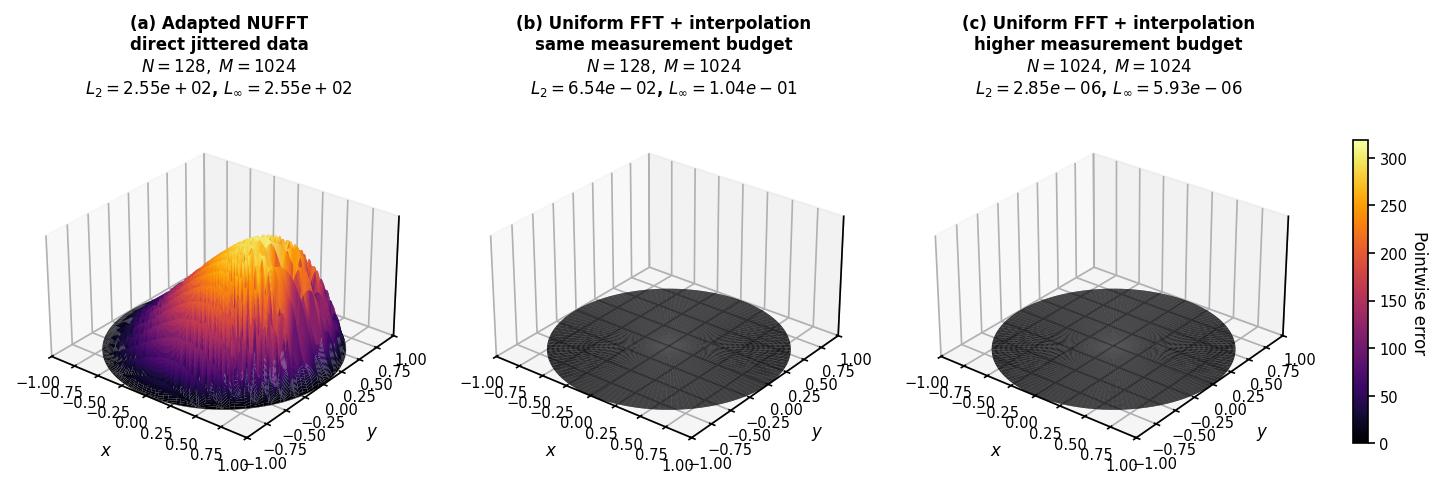

,Case,N,M,Relative L2,Relative Linf,Runtime (s)
0,Adapted NUFFT — direct jittered data,128,1024,255.000001,255.000052,0.289435
1,Adapted NUDFT — direct jittered data,128,1024,0.000002,0.000004,0.223494
2,Uniform FFT + interpolation — same measurement...,128,1024,0.065383,0.104371,0.013628
3,Uniform FFT + interpolation — higher measureme...,1024,1024,0.000003,0.000006,0.027327


In [7]:
plot_adapted_vs_highres_uniform(
    problem=problem,
    N_adapt=N_LOW_ADAPT,
    N_unif_high=N_HIGH_UNIFORM,
    M=M_FIXED_PLOTS,
    jitter_fraction=JITTER_FRACTION,
    grid_seed=GRID_SEED,
    quad_rule=QUAD_RULE,
    bc_choice=BC_CHOICE,
    maxiter_nufft=maxiter_nufft,
    tol_nufft=tol_nufft,
    reg_param=reg_param,
    eps_finufft=eps_finufft,
    num_processors=num_processors,
    use_gpu=USE_GPU,
)

Runtime Tables ($N$ vs. $M$)


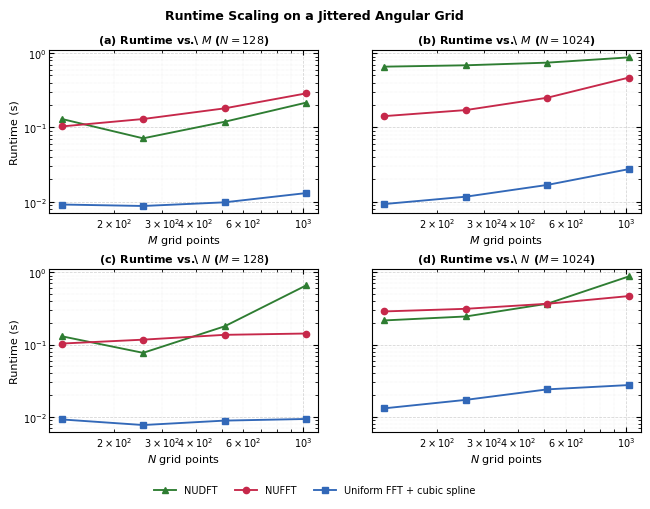

In [8]:
# Runtime (seconds) Tables for each algorithm
combined_runtime = render_combined_runtime_table(df_results)

plot_extreme_runtime_2x2(df_results)